In [5]:
import sys
import numpy
import pandas
import xarray
import geopandas
import rasterio
import sklearn

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Xarray:", xarray.__version__)
print("GeoPandas:", geopandas.__version__)
print("Rasterio:", rasterio.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.11.16 (main, Sep  1 2026, 14:15:24) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.4.6
Pandas: 3.0.6
Xarray: 2026.7.0
GeoPandas: 1.1.4
Rasterio: 1.4.4
Scikit-learn: 1.9.1


In [6]:
import imdlib as imd
import matplotlib.pyplot as plt

print("imdlib imported successfully!")

imdlib imported successfully!


In [7]:
imd.get_data(
    'rain',
    2015,
    2023,
    fn_format='yearwise',
    file_dir='../data/raw'
)

print("Rainfall data downloaded!")

File already exists: ../data/raw\rain/2015.grd. Skipping download.
Downloading: rain for year 2016


ConnectTimeout: HTTPSConnectionPool(host='imdpune.gov.in', port=443): Max retries exceeded with url: /cmpg/Griddata/rainfall.php (Caused by ConnectTimeoutError(<HTTPSConnection(host='imdpune.gov.in', port=443) at 0x1bd740f4b50>, 'Connection to imdpune.gov.in timed out. (connect timeout=None)'))

In [8]:
from pathlib import Path

file_path = Path("../data/raw/rain/2015.grd")

print("Exists:", file_path.exists())

if file_path.exists():
    print("File size:", file_path.stat().st_size / (1024 * 1024), "MB")

Exists: True
File size: 24.248027801513672 MB


In [9]:
import imdlib as imd

data = imd.open_data(
    'rain',
    2015,
    2015,
    'yearwise',
    '../data/raw'
)

print(data)

In [10]:
ds = data.get_xarray()

print(ds)

<xarray.Dataset> Size: 51MB
Dimensions:  (time: 365, lat: 129, lon: 135)
Coordinates:
  * time     (time) datetime64[us] 3kB 2015-01-01 2015-01-02 ... 2015-12-31
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
Data variables:
    rain     (time, lat, lon) float64 51MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-09-24 19:54:27.151693 Python
    references:   
    comment:      
    crs:          epsg:4326


In [12]:
basin = ds.sel(
    lat=slice(9.5, 10.5),
    lon=slice(76.0, 77.2)
)

print(basin)

<xarray.Dataset> Size: 76kB
Dimensions:  (time: 365, lat: 5, lon: 5)
Coordinates:
  * time     (time) datetime64[us] 3kB 2015-01-01 2015-01-02 ... 2015-12-31
  * lat      (lat) float64 40B 9.5 9.75 10.0 10.25 10.5
  * lon      (lon) float64 40B 76.0 76.25 76.5 76.75 77.0
Data variables:
    rain     (time, lat, lon) float64 73kB nan 2.708 0.6322 ... 0.0 0.0 0.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-09-24 19:54:27.151693 Python
    references:   
    comment:      
    crs:          epsg:4326


In [13]:
print(basin["rain"])

<xarray.DataArray 'rain' (time: 365, lat: 5, lon: 5)> Size: 73kB
array([[[       nan, 2.70759678, 0.63215786, 0.68780082, 0.82287371],
        [       nan, 2.        , 8.25298119, 0.56739819, 0.16117291],
        [0.34364086, 0.90694219, 3.78916216, 0.        , 0.        ],
        [0.64209312, 5.28425407, 1.24098325, 0.        , 0.        ],
        [0.        , 0.32121438, 0.        , 0.        , 1.17400527]],

       [[       nan, 0.        , 0.        , 0.        , 0.        ],
        [       nan, 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]],

       [[       nan, 0.        , 0.        , 0.        , 0.        ],
        [       nan, 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 

In [11]:
print("Latitude:", float(ds.lat.min()), "to", float(ds.lat.max()))
print("Longitude:", float(ds.lon.min()), "to", float(ds.lon.max()))
print("Time:", ds.time.min().values, "to", ds.time.max().values)

Latitude: 6.5 to 38.5
Longitude: 66.5 to 100.0
Time: 2015-01-01T00:00:00.000000 to 2015-12-31T00:00:00.000000


In [14]:
print("Minimum rainfall:", float(basin["rain"].min()))
print("Maximum rainfall:", float(basin["rain"].max()))
print("Mean rainfall:", float(basin["rain"].mean()))

Minimum rainfall: 0.0
Maximum rainfall: 190.0
Mean rainfall: 6.79594290978927


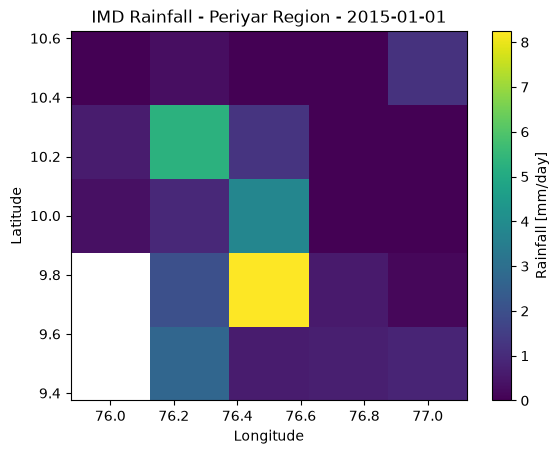

In [15]:
import matplotlib.pyplot as plt

basin["rain"].isel(time=0).plot()

plt.title("IMD Rainfall - Periyar Region - 2015-01-01")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [16]:
basin = ds.sel(
    lat=slice(9.5, 10.5),
    lon=slice(76.0, 77.2)
)

print(basin)

<xarray.Dataset> Size: 76kB
Dimensions:  (time: 365, lat: 5, lon: 5)
Coordinates:
  * time     (time) datetime64[us] 3kB 2015-01-01 2015-01-02 ... 2015-12-31
  * lat      (lat) float64 40B 9.5 9.75 10.0 10.25 10.5
  * lon      (lon) float64 40B 76.0 76.25 76.5 76.75 77.0
Data variables:
    rain     (time, lat, lon) float64 73kB nan 2.708 0.6322 ... 0.0 0.0 0.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-09-24 19:54:27.151693 Python
    references:   
    comment:      
    crs:          epsg:4326


In [17]:
daily_rainfall = basin["rain"].mean(dim=["lat", "lon"], skipna=True)

print(daily_rainfall)

<xarray.DataArray 'rain' (time: 365)> Size: 3kB
array([1.28409899e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.87918040e-01, 4.37691168e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.15101076e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.81355974e-02, 8.67334021e-02, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.87267794e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.69107253e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.33122093e-02, 0.00000000e+00,
       0.00000000e+00, 0.0000

In [18]:
rain_df = daily_rainfall.to_dataframe(name="rainfall_mm").reset_index()

print(rain_df.head())
print(rain_df.shape)

        time  rainfall_mm
0 2015-01-01     1.284099
1 2015-01-02     0.000000
2 2015-01-03     0.000000
3 2015-01-04     0.000000
4 2015-01-05     0.000000
(365, 2)


In [19]:
print(rain_df.isna().sum())

time           0
rainfall_mm    0
dtype: int64


In [20]:
print(rain_df.describe())

                      time  rainfall_mm
count                  365   365.000000
mean   2015-07-02 00:00:00     6.795943
min    2015-01-01 00:00:00     0.000000
25%    2015-04-02 00:00:00     0.086733
50%    2015-07-02 00:00:00     3.123796
75%    2015-10-01 00:00:00     9.223555
max    2015-12-31 00:00:00    69.201278
std                    NaN     9.552020


In [21]:
from pathlib import Path

output_path = Path("../data/processed/periyar_daily_rainfall_2015.csv")

rain_df.to_csv(output_path, index=False)

print("Saved successfully!")
print(output_path)

Saved successfully!
..\data\processed\periyar_daily_rainfall_2015.csv


In [22]:
import pandas as pd

check_df = pd.read_csv(output_path)

print(check_df.head())
print()
print("Shape:", check_df.shape)
print()
print("Missing values:")
print(check_df.isna().sum())

         time  rainfall_mm
0  2015-01-01     1.284099
1  2015-01-02     0.000000
2  2015-01-03     0.000000
3  2015-01-04     0.000000
4  2015-01-05     0.000000

Shape: (365, 2)

Missing values:
time           0
rainfall_mm    0
dtype: int64


In [23]:
import pandas as pd

rain_df = pd.read_csv(
    "../data/processed/periyar_daily_rainfall_2015.csv",
    parse_dates=["time"]
)

rain_df = rain_df.sort_values("time").reset_index(drop=True)

print(rain_df.head())

        time  rainfall_mm
0 2015-01-01     1.284099
1 2015-01-02     0.000000
2 2015-01-03     0.000000
3 2015-01-04     0.000000
4 2015-01-05     0.000000


In [24]:
rain_df["rainfall_3day"] = (
    rain_df["rainfall_mm"]
    .rolling(window=3)
    .sum()
)

rain_df["rainfall_7day"] = (
    rain_df["rainfall_mm"]
    .rolling(window=7)
    .sum()
)

rain_df["rainfall_15day"] = (
    rain_df["rainfall_mm"]
    .rolling(window=15)
    .sum()
)

rain_df["rainfall_3day_max"] = (
    rain_df["rainfall_mm"]
    .rolling(window=3)
    .max()
)

rain_df["rainfall_7day_max"] = (
    rain_df["rainfall_mm"]
    .rolling(window=7)
    .max()
)

In [25]:
rain_df["rainfall_previous_day"] = (
    rain_df["rainfall_mm"].shift(1)
)

In [26]:
print(rain_df.head(20))

         time  rainfall_mm  rainfall_3day  rainfall_7day  rainfall_15day  \
0  2015-01-01     1.284099            NaN            NaN             NaN   
1  2015-01-02     0.000000            NaN            NaN             NaN   
2  2015-01-03     0.000000       1.284099            NaN             NaN   
3  2015-01-04     0.000000       0.000000            NaN             NaN   
4  2015-01-05     0.000000       0.000000            NaN             NaN   
5  2015-01-06     0.000000       0.000000            NaN             NaN   
6  2015-01-07     0.000000       0.000000       1.284099             NaN   
7  2015-01-08     0.000000       0.000000       0.000000             NaN   
8  2015-01-09     0.487918       0.487918       0.487918             NaN   
9  2015-01-10     0.437691       0.925609       0.925609             NaN   
10 2015-01-11     0.000000       0.925609       0.925609             NaN   
11 2015-01-12     0.000000       0.437691       0.925609             NaN   
12 2015-01-1

In [27]:
print(rain_df.isnull().sum())

time                      0
rainfall_mm               0
rainfall_3day             2
rainfall_7day             6
rainfall_15day           14
rainfall_3day_max         2
rainfall_7day_max         6
rainfall_previous_day     1
dtype: int64


In [28]:
rain_df = rain_df.dropna().reset_index(drop=True)

print("Shape after removing incomplete rows:", rain_df.shape)
print()
print(rain_df.isnull().sum())

Shape after removing incomplete rows: (351, 8)

time                     0
rainfall_mm              0
rainfall_3day            0
rainfall_7day            0
rainfall_15day           0
rainfall_3day_max        0
rainfall_7day_max        0
rainfall_previous_day    0
dtype: int64


In [29]:
feature_path = "../data/processed/periyar_rainfall_features_2015.csv"

rain_df.to_csv(feature_path, index=False)

print("Feature dataset saved!")
print(feature_path)

Feature dataset saved!
../data/processed/periyar_rainfall_features_2015.csv


In [30]:
check_features = pd.read_csv(
    feature_path,
    parse_dates=["time"]
)

print(check_features.shape)
print(check_features.head())

(351, 8)
        time  rainfall_mm  rainfall_3day  rainfall_7day  rainfall_15day  \
0 2015-01-15          0.0            0.0       0.925609        2.209708   
1 2015-01-16          0.0            0.0       0.437691        0.925609   
2 2015-01-17          0.0            0.0       0.000000        0.925609   
3 2015-01-18          0.0            0.0       0.000000        0.925609   
4 2015-01-19          0.0            0.0       0.000000        0.925609   

   rainfall_3day_max  rainfall_7day_max  rainfall_previous_day  
0                0.0           0.487918                    0.0  
1                0.0           0.437691                    0.0  
2                0.0           0.000000                    0.0  
3                0.0           0.000000                    0.0  
4                0.0           0.000000                    0.0  
